In [4]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
import matplotlib.pyplot as plt
import numpy as np

import ex1_parametric
import ex2_over_conditioning
import ex3_data_splitting
import ex4_naive
import ex5_cort_without_inference
import ex6_bonferroni

In [7]:
# --- 1. Cấu hình tham số chung ---
iteration = 1000  # Số lần lặp
n_source = 20
p = 100
K = 5
Ka = 2
h = 15
alpha = 0.05
T = 5
s_len = 10
s_vector = [0.5] * s_len

# Danh sách n_target cần chạy (trục hoành trong ảnh mẫu: 40, 50, 60, 70)
n_target_list = [30, 40, 50, 60]

# --- 2. Định nghĩa các phương pháp cần chạy ---
# Mapping: Tên hiển thị trên đồ thị -> Hàm thực thi & màu sắc
methods = {
    "DS": {
        "func": ex3_data_splitting.data_splitting,
        "color": "green",
        "marker": "o",
        "linestyle": "-"
    },
    "Bonferroni": {
        "func": ex6_bonferroni.bonferroni,
        "color": "purple",
        "marker": "o",
        "linestyle": "-"
    },
    "Naive": {
        "func": ex4_naive.naive,
        "color": "teal", # Màu xanh két giống trong ảnh
        "marker": "o",
        "linestyle": "-"
    },
    "No inference": {
        "func": ex5_cort_without_inference.cort_without_inference,
        "color": "blue",
        "marker": "o",
        "linestyle": "-"
    },
    "PTL-SI-oc": {
        "func": ex2_over_conditioning.over_conditioning,
        "color": "gold",
        "marker": "o",
        "linestyle": "-"
    },
    "PTL-SI": {
        "func": ex1_parametric.parametric,
        "color": "red",
        "marker": "o",
        "linestyle": "-"
    }
}

# Dictionary để lưu kết quả: { "Tên Method": {"fpr": [], "tpr": []} }
experiment_results = {name: {"fpr": [], "tpr": []} for name in methods}

# --- 3. Chạy thực nghiệm ---
print(f"Bắt đầu chạy thực nghiệm với n_target = {n_target_list}...")

for n_t in n_target_list:
    print(f"\n--- Processing n_target = {n_t} ---")
    for name, config in methods.items():
        print(f"Running {name}")
        
        # Gọi hàm từ module tương ứng
        # Lưu ý: Truyền n_t (biến chạy) thay vì n_target cố định
        curr_fpr, curr_tpr = config["func"](
            iteration, n_t, n_source, p, K, Ka, h, alpha, T, s_len, s_vector
        )
        
        # Lưu kết quả
        experiment_results[name]["fpr"].append(curr_fpr)
        experiment_results[name]["tpr"].append(curr_tpr)
        print(f"Done -----> (FPR: {curr_fpr:.2f}, TPR: {curr_tpr:.2f})")
        print("-" * 40)

Bắt đầu chạy thực nghiệm với n_target = [30, 40, 50, 60]...

--- Processing n_target = 30 ---
Running DS
Iteration 0
Iteration 50
Iteration 100
Iteration 150
Iteration 200
Iteration 250
Iteration 300
Iteration 350
Iteration 400
Iteration 450
Iteration 500
Iteration 550
Iteration 600
Iteration 650
Iteration 700
Iteration 750
Iteration 800
Iteration 850
Iteration 900
Iteration 950
Done -----> (FPR: 0.16, TPR: 0.21)
----------------------------------------
Running Bonferroni
Done -----> (FPR: 0.00, TPR: 0.03)
----------------------------------------
Running Naive
Iteration 0
Iteration 50
Iteration 100
Iteration 150
Iteration 200
Iteration 250
Iteration 300
Iteration 350
Iteration 400
Iteration 450
Iteration 500
Iteration 550
Iteration 600
Iteration 650
Iteration 700
Iteration 750
Iteration 800
Iteration 850
Iteration 900
Iteration 950
Done -----> (FPR: 0.13, TPR: 0.31)
----------------------------------------
Running No inference
Iteration 0
Iteration 50
Iteration 100
Iteration 150
Iterat

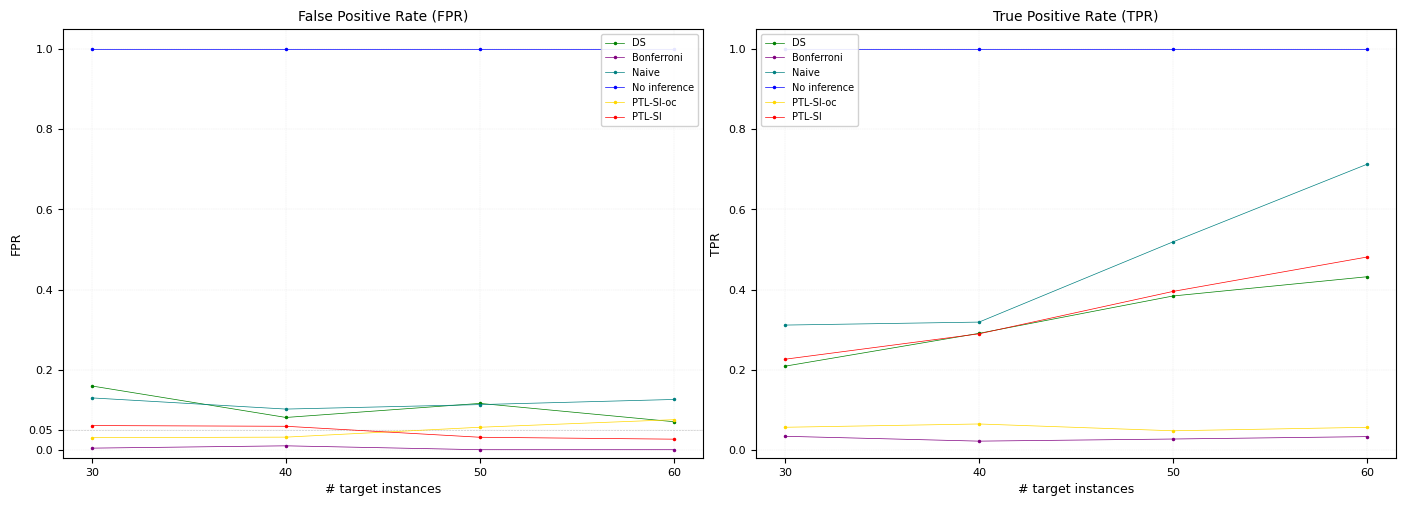

In [8]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# --- 4. Vẽ đồ thị (Visualization) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# === BIỂU ĐỒ FPR (Bên trái) ===

# Vẽ đường kẻ alpha mảnh
ax1.axhline(y=alpha, color='gray', linestyle='--', linewidth=0.4, alpha=0.5)

for name, data in experiment_results.items():
    config = methods[name]
    ax1.plot(n_target_list, data["fpr"], 
             label=name, 
             color=config["color"], 
             marker=config["marker"], 
             markersize=1.5,   
             linewidth=0.5)    

# --- XỬ LÝ TRỤC TUNG (Y-AXIS) ---
# 1. Thêm lại số 0.0 vào danh sách ticks chuẩn
standard_ticks = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

# 2. Gộp alpha (0.05) vào danh sách này
fpr_ticks = sorted(list(set(standard_ticks + [alpha])))
ax1.set_yticks(fpr_ticks)

# 3. Hàm định dạng số
def format_func(value, tick_number):
    if abs(value - alpha) < 1e-9: 
        return f'{alpha}' # In ra 0.05
    return f'{value:.1f}' # In ra 0.0, 0.2...

ax1.yaxis.set_major_formatter(FuncFormatter(format_func))

# Thiết lập trục và nhãn
ax1.set_xlabel("# target instances", fontsize=9)
ax1.set_ylabel("FPR", fontsize=9)
ax1.set_xticks(n_target_list)
ax1.tick_params(axis='both', which='major', labelsize=8) 
ax1.set_ylim(-0.02, 1.05) 
ax1.legend(loc="upper right", framealpha=0.9, fontsize=7)
ax1.grid(True, linestyle='--', alpha=0.3, linewidth=0.3)
ax1.set_title("False Positive Rate (FPR)", fontsize=10)

# === BIỂU ĐỒ TPR (Bên phải) ===
for name, data in experiment_results.items():
    config = methods[name]
    ax2.plot(n_target_list, data["tpr"], 
             label=name, 
             color=config["color"], 
             marker=config["marker"],
             markersize=1.5,
             linewidth=0.5)

ax2.set_xlabel("# target instances", fontsize=9)
ax2.set_ylabel("TPR", fontsize=9)
ax2.set_xticks(n_target_list)
# Bên TPR dùng danh sách ticks chuẩn (có số 0.0)
ax2.set_yticks(standard_ticks) 
ax2.tick_params(axis='both', which='major', labelsize=8)
ax2.set_ylim(-0.02, 1.05)
ax2.legend(loc="upper left", framealpha=0.9, fontsize=7)
ax2.grid(True, linestyle='--', alpha=0.3, linewidth=0.3)
ax2.set_title("True Positive Rate (TPR)", fontsize=10)

plt.tight_layout(pad=0.5)
plt.show()

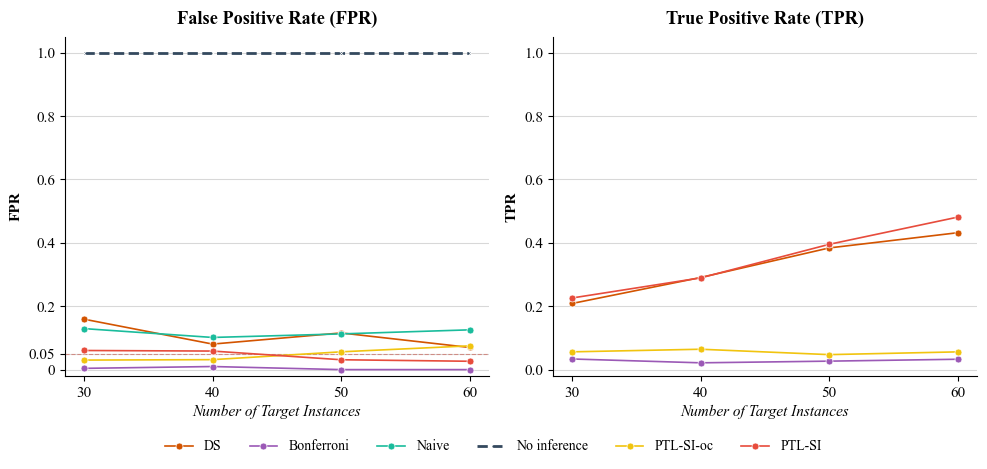

In [15]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# --- CẤU HÌNH ---
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 0.8

# Đảm bảo danh sách n_target khớp với dữ liệu chạy thực nghiệm
n_target_list = [30, 40, 50, 60] 

# Định nghĩa màu sắc và style
colors = {
    "No inference": "#34495e", 
    "Naive":        "#1abc9c", 
    "Bonferroni":   "#9b59b6", 
    "DS":           "#d35400", 
    "PTL-SI-oc":    "#f1c40f", 
    "PTL-SI":       "#e74c3c"  
}

methods = {
    "No inference": {"color": colors["No inference"], "marker": "x", "ls": "--", "lw": 2.0, "zorder": 2}, 
    "Naive":        {"color": colors["Naive"],        "marker": "o", "ls": "-",  "lw": 1.2, "zorder": 3},
    "Bonferroni":   {"color": colors["Bonferroni"],   "marker": "o", "ls": "-",  "lw": 1.2, "zorder": 3},
    "DS":           {"color": colors["DS"],           "marker": "o", "ls": "-",  "lw": 1.2, "zorder": 3},
    "PTL-SI-oc":    {"color": colors["PTL-SI-oc"],    "marker": "o", "ls": "-",  "lw": 1.2, "zorder": 3},
    "PTL-SI":       {"color": colors["PTL-SI"],       "marker": "o", "ls": "-",  "lw": 1.2, "zorder": 3}
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5))

def format_func(value, tick_number):
    if abs(value - alpha) < 1e-9: return f'{alpha}'
    if value == 0.0: return '0'
    return f'{value:.1f}'

# === 1. VẼ BIỂU ĐỒ FPR (Giữ nguyên tất cả) ===
ax1.axhline(y=alpha, color='#e74c3c', linestyle='--', linewidth=0.8, alpha=0.6, zorder=1)

for name, data in experiment_results.items():
    cfg = methods[name]
    ax1.plot(n_target_list, data["fpr"], 
             label=name, 
             color=cfg["color"], 
             linestyle=cfg["ls"],
             marker=cfg["marker"], 
             markersize=5,      
             linewidth=cfg.get("lw", 1.2),     
             markeredgecolor='white', 
             markeredgewidth=0.5,
             zorder=cfg.get("zorder", 3)) 

# Tinh chỉnh trục FPR
standard_ticks = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
fpr_ticks = sorted(list(set(standard_ticks + [alpha])))
ax1.set_yticks(fpr_ticks)
ax1.yaxis.set_major_formatter(FuncFormatter(format_func))
ax1.set_title("False Positive Rate (FPR)", fontweight='bold', pad=10)
ax1.set_xlabel("Number of Target Instances", style='italic')
ax1.set_ylabel("FPR", fontweight='bold')
ax1.set_xticks(n_target_list)
ax1.set_ylim(-0.02, 1.05)
ax1.grid(axis='y', linestyle='-', alpha=0.3, color='gray', zorder=0)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# === 2. VẼ BIỂU ĐỒ TPR (Bỏ Naive và No inference) ===
for name, data in experiment_results.items():
    # [QUAN TRỌNG] Thêm điều kiện lọc tại đây
    if name in ["Naive", "No inference"]:
        continue
        
    cfg = methods[name]
    ax2.plot(n_target_list, data["tpr"], 
             label=name, 
             color=cfg["color"], 
             linestyle=cfg["ls"],
             marker=cfg["marker"],
             markersize=5,
             linewidth=cfg.get("lw", 1.2),
             markeredgecolor='white',
             markeredgewidth=0.5,
             zorder=cfg.get("zorder", 3))

# Tinh chỉnh trục TPR
ax2.set_title("True Positive Rate (TPR)", fontweight='bold', pad=10)
ax2.set_xlabel("Number of Target Instances", style='italic')
ax2.set_ylabel("TPR", fontweight='bold')
ax2.set_xticks(n_target_list)
ax2.set_yticks(standard_ticks)
ax2.set_ylim(-0.02, 1.05)
ax2.grid(axis='y', linestyle='-', alpha=0.3, color='gray', zorder=0)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# --- LEGEND ---
# Lấy legend từ ax1 (FPR) để hiển thị đầy đủ tất cả các phương pháp trong chú thích
# Nếu bạn muốn chú thích chỉ hiện các đường có trong TPR, hãy đổi thành ax2.get_legend_handles_labels()
handles, labels = ax1.get_legend_handles_labels()

fig.legend(handles, labels, 
           loc='lower center', 
           bbox_to_anchor=(0.5, -0.05), 
           ncol=6, 
           frameon=False, 
           fontsize=10)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15) 
plt.show()